In [156]:
import pandas as pd
import seaborn as sb
import math
import numpy as np
import matplotlib.pyplot as plt

d = pd.read_excel("modelling_data.xlsx")

##ed = pd.read_excel("evaluation_data.xlsx")

Xm = d
#Xe = ed.drop(['ROW_ID','claimcount'], axis = 1)
#Ye = ed['claimcount']

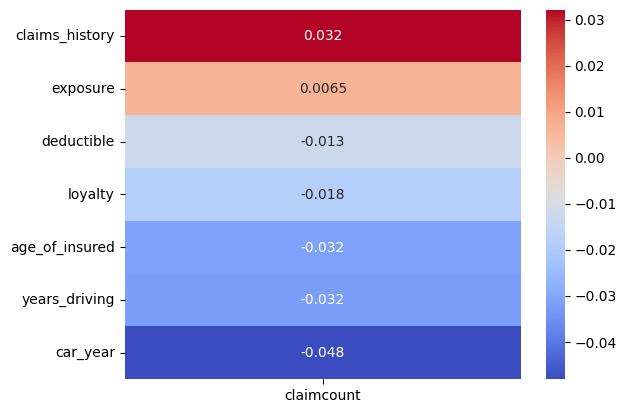

In [157]:
corrholder = Xm
corr = corrholder.corr(numeric_only=True).sort_values(by='claimcount', ascending=False)
corr2 = corr.drop('claimcount')
sb.heatmap(corr2[['claimcount']], cmap='coolwarm', annot=True)
plt.show()

In [158]:
x_ord = ['annual_mileage','annual_income','credit_band', 'vehicle_value']
x_bin = ['gender', 'winter_tires']
x_one_hot = ['location', 'ownership', 'occupation', 'marital_status', 'car_model']

am_r = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-25000']
ai_r = ['0-10000', '10000-30000', '30000-50000','50000-75000', '75000-100000', '100000-150000', '150000-1000000']
cb_r = ['K', 'I', 'J', 'F', 'E', 'D', 'C', 'B', 'A', 'AA', 'AAA']
vv_r = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-25000', '25000-30000', '30000-50000', '50000-75000', '75000-100000']

g_r = ['Male', 'Female']
wt_r = ['Yes', 'No']

l_r = ['Mississauga', 'Oakville','Toronto', 'Burlington', 'Hamilton', 'Brampton']
ow_r = ['financed', 'leased', 'owned']
oc_r = ['Military', 'Farming', 'Government', 'Healthcare', 'Businessowner', 'Unemployed', 'Trades', 'Industrial', 'Office', 'Education', 'Retail']
ms_r = ['Widowed', 'Seperated', 'Single', 'Married'] 
cm_r = ['Kia', 'Jeep', 'Hyundai', 'Cadillac', 'Volvo', 'Dodge', 'Ford', 'Nissan', 'Audi', 'Subaru', 'BMW', 'Toyota', 'Mercedes', 'Honda']

#print(Xm.head())

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
cb_h = OrdinalEncoder(categories=[cb_r], handle_unknown='use_encoded_value', unknown_value=-1)
cb_h2 = cb_h.fit_transform(Xm[['credit_band']])
cb_df = pd.DataFrame(cb_h2, columns=cb_h.get_feature_names_out())
am_h = OrdinalEncoder(categories=[am_r], handle_unknown='use_encoded_value', unknown_value=-1)
am_h2 = am_h.fit_transform(Xm[['annual_mileage']])
am_df = pd.DataFrame(am_h2, columns=am_h.get_feature_names_out())
ai_h = OrdinalEncoder(categories=[ai_r], handle_unknown='use_encoded_value', unknown_value=-1)
ai_h2 = ai_h.fit_transform(Xm[['annual_income']])
ai_df = pd.DataFrame(ai_h2, columns=ai_h.get_feature_names_out())
vv_h = OrdinalEncoder(categories=[vv_r], handle_unknown='use_encoded_value', unknown_value=-1)
vv_h2 = vv_h.fit_transform(Xm[['vehicle_value']])
vv_df = pd.DataFrame(vv_h2, columns=vv_h.get_feature_names_out())

g_h = OrdinalEncoder(categories=[g_r], handle_unknown='use_encoded_value', unknown_value= -1)
g_h2 = g_h.fit_transform(Xm[['gender']])
g_df = pd.DataFrame(g_h2, columns=g_h.get_feature_names_out())
wt_h = OrdinalEncoder(categories=[wt_r], handle_unknown='use_encoded_value', unknown_value= -1)
wt_h2 = wt_h.fit_transform(Xm[['winter_tires']])
wt_df = pd.DataFrame(wt_h2, columns=wt_h.get_feature_names_out())

l_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
l_h2 = l_h.fit_transform(Xm[['location']])
l_df = pd.DataFrame(l_h2, columns=l_h.get_feature_names_out())
ow_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ow_h2 = ow_h.fit_transform(Xm[['ownership']])
ow_df = pd.DataFrame(ow_h2, columns=ow_h.get_feature_names_out())
oc_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
oc_h2 = oc_h.fit_transform(Xm[['occupation']])
oc_df = pd.DataFrame(oc_h2, columns=oc_h.get_feature_names_out())
ms_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ms_h2 = ms_h.fit_transform(Xm[['marital_status']])
ms_df = pd.DataFrame(ms_h2, columns=ms_h.get_feature_names_out())
cm_h = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cm_h2 = cm_h.fit_transform(Xm[['car_model']])
cm_df = pd.DataFrame(cm_h2, columns=cm_h.get_feature_names_out())

Xm_n = Xm.drop(['annual_mileage', 'winter_tires', 'gender', 'annual_income', 'credit_band', 'vehicle_value', 'location', 'ownership', 'occupation', 'marital_status', 'car_model'], axis = 1)

Xm2 = pd.concat([Xm_n, cb_df, am_df, ai_df, vv_df, g_df, wt_df, l_df, ow_df, oc_df, ms_df, cm_df], axis=1)

In [159]:
Xm2.head(10)

,deductible,claims_history,years_driving,loyalty,age_of_insured,car_year,exposure,claimcount,credit_band,annual_mileage,...,car_model_Ford,car_model_Honda,car_model_Hyundai,car_model_Jeep,car_model_Kia,car_model_Mercedes,car_model_Nissan,car_model_Subaru,car_model_Toyota,car_model_Volvo
0,2000,0,18,2,40,2024,0.663020,0,10.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000,0,28,4,46,2024,0.294235,0,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1500,0,23,13,44,2015,0.617784,0,10.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1500,0,22,7,42,2013,0.560516,0,9.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1000,0,30,13,48,2016,0.193881,0,10.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1500,0,18,5,37,2024,0.650545,0,10.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,2000,0,28,9,47,2021,0.779107,0,9.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2000,0,22,11,40,2012,0.111248,0,10.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1000,0,17,5,35,2017,0.647513,0,10.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1500,0,20,6,38,2020,0.543066,0,9.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [160]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Function to calculate VIF
def calculate_vif(dataframe):
    # Add a constant to the DataFrame (intercept term)
    df_with_constant = add_constant(dataframe)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_with_constant.columns
    vif_data["VIF"] = [variance_inflation_factor(df_with_constant.values, i)
                       for i in range(df_with_constant.shape[1])]

    return vif_data

# Calculate VIF for encoded data
vif_df = calculate_vif(Xm2.head(110))
vif_df

c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,const,0.000000
1,deductible,1.824109
2,claims_history,3.575622
3,years_driving,17.916139
4,loyalty,1.574305
5,age_of_insured,17.967953
6,car_year,1.956791
7,exposure,1.506744
8,claimcount,NaN
9,credit_band,1.637118


In [161]:
Xm2.drop(['location_Brampton', 'ownership_financed', 'occupation_not provided', 'marital_status_not provided', 'car_model_Audi'], axis=1, inplace=True)
vif_df = calculate_vif(Xm2.head(110))
vif_df

c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Feature,VIF
0,const,457276.351811
1,deductible,1.824109
2,claims_history,3.575622
3,years_driving,17.916139
4,loyalty,1.574305
5,age_of_insured,17.967953
6,car_year,1.956791
7,exposure,1.506744
8,claimcount,NaN
9,credit_band,1.637118


In [202]:
pd.Series(Y_h).value_counts()

claimcount
0    49354
1      638
2        8
Name: count, dtype: int64

In [313]:
from sklearn.linear_model import LogisticRegression, LinearRegression, SGDRegressor, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import LinearSVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split

from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier

clfs = [
    ('Logistic Regression', LogisticRegression(solver='liblinear', max_iter=2000, class_weight='balanced')),
    ('Poisson Regression', PoissonRegressor(solver='newton-cholesky', max_iter=2000)),
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(random_state=42, class_weight='balanced')),
    #('Linear SVM', LinearSVC(random_state=42, max_iter=1000, dual='False')),
    #('XGBoost', XGBClassifier(random_state=42)),
    ('AdaBoost', AdaBoostClassifier(random_state=42, algorithm='SAMME')),
    #('Gradient Boost', GradientBoostingClassifier(random_state=42)),
    ('Bagging', BaggingClassifier(random_state=42)),
    #('CatBoost', CatBoostClassifier(random_state=42, verbose=0))
]

Y_h = Xm2['claimcount']
X_h = Xm2.drop(['claimcount'], axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X_h, Y_h, test_size=0.2, random_state=42, stratify=Y_h)


In [314]:
pd.Series(Y_train).value_counts()

claimcount
0    39483
1      511
2        6
Name: count, dtype: int64

In [220]:
clf = AdaBoostClassifier(random_state=42, algorithm='SAMME')
hold = cross_val_score(clf, X_train, Y_train, cv=5, n_jobs=-1)

for i in hold:
    print(i)

KeyboardInterrupt: 

In [221]:
# Create KFold object with 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

# Evaluate each classifier using cross-validation
for clf_name, clf in clfs:
    cv_scores = cross_val_score(clf, X_train, Y_train, cv=kf)
    results[clf_name] = cv_scores

cv_scores_df = pd.DataFrame(results)

c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Sta

In [222]:
cv_scores_df.mean()

Logistic Regression    0.980253
Poisson Regression     0.029696
KNN                    0.987011
Decision Tree          0.972211
Random Forest          0.987074
AdaBoost               0.987074
Bagging                0.986905
dtype: float64

In [223]:
cv_scores_df

,Logistic Regression,Poisson Regression,KNN,Decision Tree,Random Forest,AdaBoost,Bagging
0,0.979579,0.034539,0.987158,0.970316,0.987158,0.987158,0.986947
1,0.983368,0.028050,0.986947,0.970947,0.986947,0.986947,0.986947
2,0.978947,0.029957,0.985684,0.972632,0.985684,0.985684,0.985684
3,0.979368,0.027605,0.987789,0.976211,0.988000,0.988000,0.987789
4,0.978737,0.028977,0.984421,0.969474,0.984632,0.984632,0.984211
5,0.978526,0.039442,0.986737,0.969053,0.986947,0.986947,0.986737
6,0.981684,0.012013,0.987789,0.975368,0.987789,0.987789,0.987789
7,0.978737,0.029689,0.988421,0.973263,0.988421,0.988421,0.988211
8,0.980211,0.030820,0.986105,0.971789,0.986105,0.986105,0.985684
9,0.983368,0.035868,0.989053,0.973053,0.989053,0.989053,0.989053


Text(0.5, 1.0, 'Cross-Validation Scores for Different Classifiers')

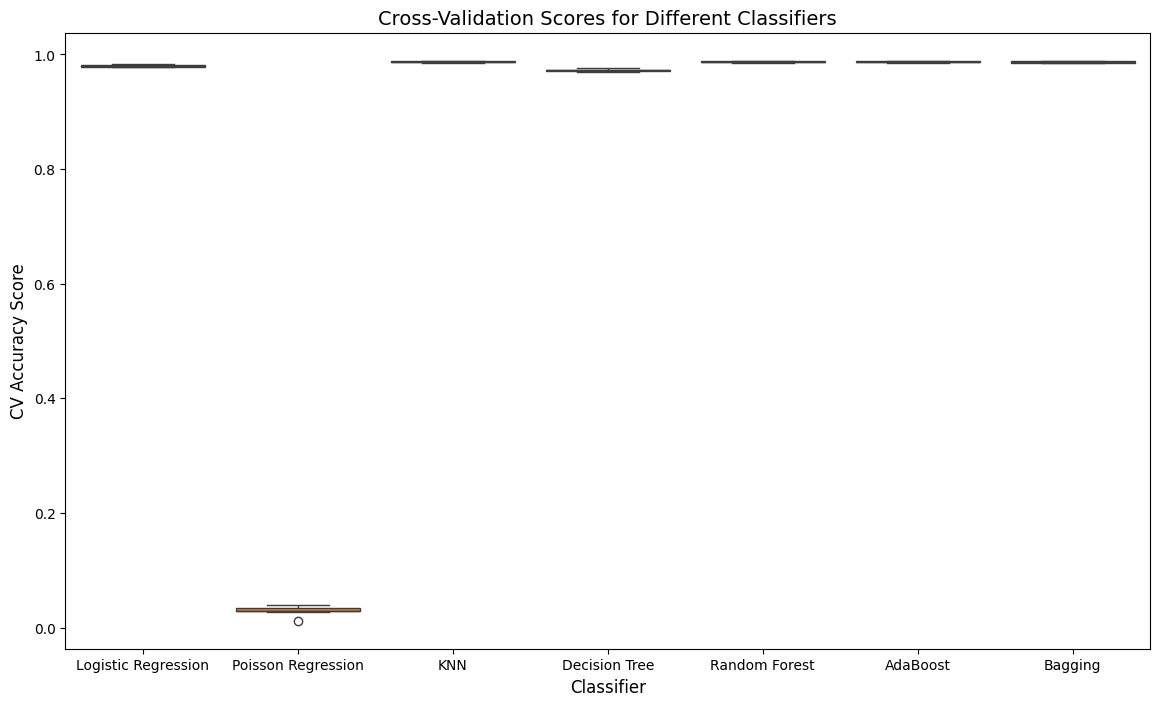

In [224]:
# Plot scores
fig, ax = plt.subplots(figsize=(14, 8))
sb.boxplot(cv_scores_df)

# Add axis labels
ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('CV Accuracy Score', fontsize=12)
ax.set_title('Cross-Validation Scores for Different Classifiers', fontsize=14)

In [239]:
pd.Series(Y_test).value_counts()

claimcount
0    2468
1      32
Name: count, dtype: int64

In [300]:
from sklearn.naive_bayes import MultinomialNB

models = [DecisionTreeClassifier(class_weight='balanced'),
RandomForestClassifier(random_state=42, class_weight='balanced'),
XGBClassifier(random_state=42),
GradientBoostingClassifier(random_state=42),
BaggingClassifier(random_state=42),
CatBoostClassifier(random_state=42, verbose=0)
]

In [339]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler

wt = {0: 0.98708, 1: 0.01276, 2: 0.00016}

X_tr, Y_tr = SMOTE(random_state=42).fit_resample(X_train, Y_train)

model = models[1]
model.fit(X_tr, Y_tr)

ypred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print(model)
print("RMSE: ", math.sqrt(mean_squared_error(Y_test, ypred)))
print("R2: ", r2_score(Y_test, ypred))
print(pd.Series(ypred).value_counts())
#print(pd.Series(list(ypred)).value_counts())
print("--------------------")

c:\Users\Stavy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


RandomForestClassifier(class_weight='balanced', random_state=42)
RMSE:  0.1161895003862225
R2:  -0.012875523600375027
0    10000
Name: count, dtype: int64
--------------------


In [340]:
ypred = model.predict(X_h)

from sklearn.metrics import mean_squared_error, r2_score
print(model)
print("RMSE: ", math.sqrt(mean_squared_error(Y_h, ypred)))
print("R2: ", r2_score(Y_test, ypred))
print(pd.Series(ypred).value_counts())
#print(pd.Series(list(ypred)).value_counts())
print("--------------------")

RandomForestClassifier(class_weight='balanced', random_state=42)
RMSE:  0.05196152422706632


ValueError: Found input variables with inconsistent numbers of samples: [10000, 50000]

In [ ]:
Y_test.

In [321]:
Y_dummy = np.zeros(10000)

In [322]:
print("RMSE: ", math.sqrt(mean_squared_error(Y_test, Y_dummy)))

RMSE:  0.1161895003862225


In [341]:

pd.Series(Y_test).value_counts()

claimcount
0    9871
1     127
2       2
Name: count, dtype: int64

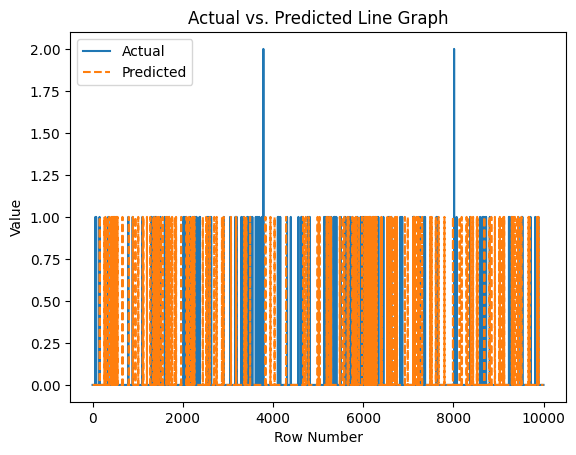

In [319]:
Av = pd.DataFrame(Y_test)
Pv = pd.DataFrame(ypred)

Av = Av.iloc[1:].reset_index(drop=True)
Pv = Pv.iloc[1:].reset_index(drop=True)

Av.columns = ['Actual']
Pv.columns = ['Predicted']

AvP = pd.concat([Av, Pv], axis=1)

AvP.insert(0, 'Row Number', range(1, len(AvP) + 1))

#print(AvP.tail(20))

plt.plot(AvP['Row Number'], AvP['Actual'], label='Actual', linestyle='-')
plt.plot(AvP['Row Number'], AvP['Predicted'], label='Predicted', linestyle='--')

plt.xlabel("Row Number")  # X-axis label
plt.ylabel("Value")       # Y-axis label
plt.title("Actual vs. Predicted Line Graph")
plt.legend()              # Show legend

plt.show()

In [320]:
AvP.to_csv('AvP2.csv', index='False')


PermissionError: [Errno 13] Permission denied: 'AvP2.csv'

In [114]:
"""
Xm.replace({'annual_mileage':{'0-5000':0, '5000-10000':1,'10000-15000':2,'15000-20000':3,'20000-25000':4}},inplace=True)
Xm['annual_mileage'] = Xm['annual_mileage'].astype('int')
Xm.replace({'winter_tires':{'not provided':0, 'No':1, 'Yes':2}},inplace=True)
Xm['winter_tires'] = Xm['winter_tires'].astype('int')
Xm.replace({'gender':{'Female':0, 'Male':1}},inplace=True)
Xm['gender'] = Xm['gender'].astype('int')
Xm.replace({'location':{'Mississauga':0, 'Oakville':1,'Toronto':2,'Burlington':3, 'Hamilton':4,'Brampton':5}},inplace=True)
Xm['location'] = Xm['location'].astype('int')
Xm.replace({'annual_income':{'0-10000':0, '10000-30000':1, '30000-50000':2,'50000-75000':3, '75000-100000':4, '100000-150000':5, '150000-1000000':6}},inplace=True)
Xm['annual_income'] = Xm['annual_income'].astype('int')
Xm.replace({'ownership':{'not provided':0, 'financed':1,'leased':2, 'owned':3}},inplace=True)
Xm['ownership'] = Xm['ownership'].astype('int')
Xm.replace({'occupation':{'not provided':0, 'Military':1, 'Farming':2, 'Government':3, 'Healthcare':4, 'Businessowner':5, 'Unemployed':6, 'Trades':7, 'Industrial':8, 'Office':9, 'Education':10, 'Retail':11}},inplace=True)
Xm['occupation'] = Xm['occupation'].astype('int')
Xm.replace({'credit_band':{'not provided':0, 'K':1, 'I':2, 'J':3, 'F':4, 'E':5, 'D':6, 'C':7, 'B':8, 'A':9, 'AA':10, 'AAA':11}},inplace=True)
Xm['credit_band'] = Xm['credit_band'].astype('int')
Xm.replace({'marital_status':{'not provided':0, 'Widowed':1, 'Seperated':2, 'Single':3, 'Married':4}},inplace=True)
Xm['marital_status'] = Xm['marital_status'].astype('int')
Xm.replace({'vehicle_value':{'0-5000':0, '5000-10000':1, '10000-15000':2, '15000-20000':3, '20000-25000':4, '25000-30000':5, '30000-50000':6, '50000-75000':7, '75000-100000':8}},inplace=True)
Xm['vehicle_value'] = Xm['vehicle_value'].astype('int')
Xm.replace({'car_model':{'Kia':0, 'Jeep':1, 'Hyundai':2, 'Cadillac':3, 'Volvo':4, 'Dodge':5, 'Ford':6, 'Nissan':7, 'Audi':8, 'Subaru':9, 'BMW':10, 'Toyota':11, 'Mercedes':12, 'Honda':13}},inplace=True)
Xm['car_model'] = Xm['car_model'].astype('int')

Xe.replace({'annual_mileage':{'0-5000':0, '5000-10000':1,'10000-15000':2,'15000-20000':3,'20000-25000':4}},inplace=True)
Xm['annual_mileage'] = Xm['annual_mileage'].astype('int')
Xe.replace({'winter_tires':{'not provided':0, 'No':1, 'Yes':2}},inplace=True)
Xm['winter_tires'] = Xm['winter_tires'].astype('int')
Xe.replace({'gender':{'Female':0, 'Male':1}},inplace=True)
Xm['gender'] = Xm['gender'].astype('int')
Xe.replace({'location':{'Mississauga':0, 'Oakville':1,'Toronto':2,'Burlington':3, 'Hamilton':4,'Brampton':5}},inplace=True)
Xm['location'] = Xm['location'].astype('int')
Xe.replace({'annual_income':{'0-10000':0, '10000-30000':1, '30000-50000':2,'50000-75000':3, '75000-100000':4, '100000-150000':5, '150000-1000000':6}},inplace=True)
Xm['annual_income'] = Xm['annual_income'].astype('int')
Xe.replace({'ownership':{'not provided':0, 'financed':1,'leased':2, 'owned':3}},inplace=True)
Xm['ownership'] = Xm['ownership'].astype('int')
Xe.replace({'occupation':{'not provided':0, 'Military':1, 'Farming':2, 'Government':3, 'Healthcare':4, 'Businessowner':5, 'Unemployed':6, 'Trades':7, 'Industrial':8, 'Office':9, 'Education':10, 'Retail':11}},inplace=True)
Xm['occupation'] = Xm['occupation'].astype('int')
Xe.replace({'credit_band':{'not provided':0, 'K':1, 'I':2, 'J':3, 'F':4, 'E':5, 'D':6, 'C':7, 'B':8, 'A':9, 'AA':10, 'AAA':11}},inplace=True)
Xm['credit_band'] = Xm['credit_band'].astype('int')
Xe.replace({'marital_status':{'not provided':0, 'Widowed':1, 'Seperated':2, 'Single':3, 'Married':4}},inplace=True)
Xm['marital_status'] = Xm['marital_status'].astype('int')
Xe.replace({'vehicle_value':{'0-5000':0, '5000-10000':1, '10000-15000':2, '15000-20000':3, '20000-25000':4, '25000-30000':5, '30000-50000':6, '50000-75000':7, '75000-100000':8}},inplace=True)
Xm['vehicle_value'] = Xm['vehicle_value'].astype('int')
Xe.replace({'car_model':{'Kia':0, 'Jeep':1, 'Hyundai':2, 'Cadillac':3, 'Volvo':4, 'Dodge':5, 'Ford':6, 'Nissan':7, 'Audi':8, 'Subaru':9, 'BMW':10, 'Toyota':11, 'Mercedes':12, 'Honda':13}},inplace=True)
Xm['car_model'] = Xm['car_model'].astype('int')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xs = scaler.fit_transform(Xm)

from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(Xm, Ym, test_size=0.9, random_state=10, stratify=Ym)

from sklearn.linear_model import PoissonRegressor
model = PoissonRegressor()
model.fit(Xtrain, Ytrain)

ypred = model.predict(Xtest)


#print(d.head())

from sklearn.metrics import mean_squared_error, r2_score
print("RMSE: ", math.sqrt(mean_squared_error(Ytest, ypred)))
print("R2: ", r2_score(Ytest, ypred))

Av = pd.DataFrame(Ytest)
Pv = pd.DataFrame(ypred)

Av = Av.iloc[1:].reset_index(drop=True)
Pv = Pv.iloc[1:].reset_index(drop=True)

Av.columns = ['Actual']
Pv.columns = ['Predicted']

AvP = pd.concat([Av, Pv], axis=1)

AvP.insert(0, 'Row Number', range(1, len(AvP) + 1))

#print(AvP.tail(20))

plt.plot(AvP['Row Number'], AvP['Actual'], label='Actual', linestyle='-')
plt.plot(AvP['Row Number'], AvP['Predicted'], label='Predicted', linestyle='--')

plt.xlabel("Row Number")  # X-axis label
plt.ylabel("Value")       # Y-axis label
plt.title("Actual vs. Predicted Line Graph")
plt.legend()              # Show legend

plt.show()


#AvP.to_csv('AvP.csv', index=False)

Av.to_csv('ActualValues.csv', index=False)
Pv.to_csv('PredValues.csv', index=False)

from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

regr = OLS(y, add_constant(X)).fit()
print(regr.aic)
"""

'\nXm.replace({\'annual_mileage\':{\'0-5000\':0, \'5000-10000\':1,\'10000-15000\':2,\'15000-20000\':3,\'20000-25000\':4}},inplace=True)\nXm[\'annual_mileage\'] = Xm[\'annual_mileage\'].astype(\'int\')\nXm.replace({\'winter_tires\':{\'not provided\':0, \'No\':1, \'Yes\':2}},inplace=True)\nXm[\'winter_tires\'] = Xm[\'winter_tires\'].astype(\'int\')\nXm.replace({\'gender\':{\'Female\':0, \'Male\':1}},inplace=True)\nXm[\'gender\'] = Xm[\'gender\'].astype(\'int\')\nXm.replace({\'location\':{\'Mississauga\':0, \'Oakville\':1,\'Toronto\':2,\'Burlington\':3, \'Hamilton\':4,\'Brampton\':5}},inplace=True)\nXm[\'location\'] = Xm[\'location\'].astype(\'int\')\nXm.replace({\'annual_income\':{\'0-10000\':0, \'10000-30000\':1, \'30000-50000\':2,\'50000-75000\':3, \'75000-100000\':4, \'100000-150000\':5, \'150000-1000000\':6}},inplace=True)\nXm[\'annual_income\'] = Xm[\'annual_income\'].astype(\'int\')\nXm.replace({\'ownership\':{\'not provided\':0, \'financed\':1,\'leased\':2, \'owned\':3}},inplace=T